# 🕵️‍♂️ HAI 2025 Test Data & Prediction Analysis
이 노트북은 모델(V10)이 예측한 확률값과 실제 Test 이미지를 함께 띄워, 모델의 판단 근거를 시각적으로 분석합니다.

In [2]:
!pip install opencv-python pandas matplotlib

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   -------- ------------------------------- 8.1/40.2 MB 43.1 MB/s eta 0:00:01
   --------------------- ------------------ 21.2/40.2 MB 52.7 MB/s eta 0:00:01
   ---------------------------------- ----- 34.3/40.2 MB 56.0 MB/s eta 0:00:01
   ---------------------------------------- 40.2/40.2 MB 51.3 MB/s eta 0:00:00


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os
import glob
import random

# 1. Load Predictions (V10)
pred_path = '../data/submission/final_ensemble_v10.csv'
df = pd.read_csv(pred_path)
print(f"Loaded {len(df)} predictions.")

# 2. Image Path Mapping
processed_dir = '../data/processed/test'

def get_image_path(filename):
    base = os.path.splitext(filename)[0]
    # Check folder
    folder = os.path.join(processed_dir, base)
    if os.path.isdir(folder):
        # Get first image
        imgs = glob.glob(os.path.join(folder, '*.jpg'))
        if imgs: return imgs[0]
    return None

df['img_path'] = df['filename'].apply(get_image_path)
valid_df = df.dropna(subset=['img_path'])
print(f"Found images for {len(valid_df)} videos.")

Loaded 500 predictions.
Found images for 500 videos.


In [4]:
# 3. Visualization Function
def show_samples(data, title="Samples"):
    plt.figure(figsize=(15, 10))
    plt.suptitle(title, fontsize=16)
    
    for i, (_, row) in enumerate(data.iterrows()):
        if i >= 10: break # Show top 10
        
        img = cv2.imread(row['img_path'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(2, 5, i+1)
        plt.imshow(img)
        prob = row['prob']
        label = "FAKE" if prob > 0.5 else "REAL"
        color = 'red' if prob > 0.5 else 'green'
        plt.title(f"{label}\n({prob:.4f})", color=color, fontsize=12)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

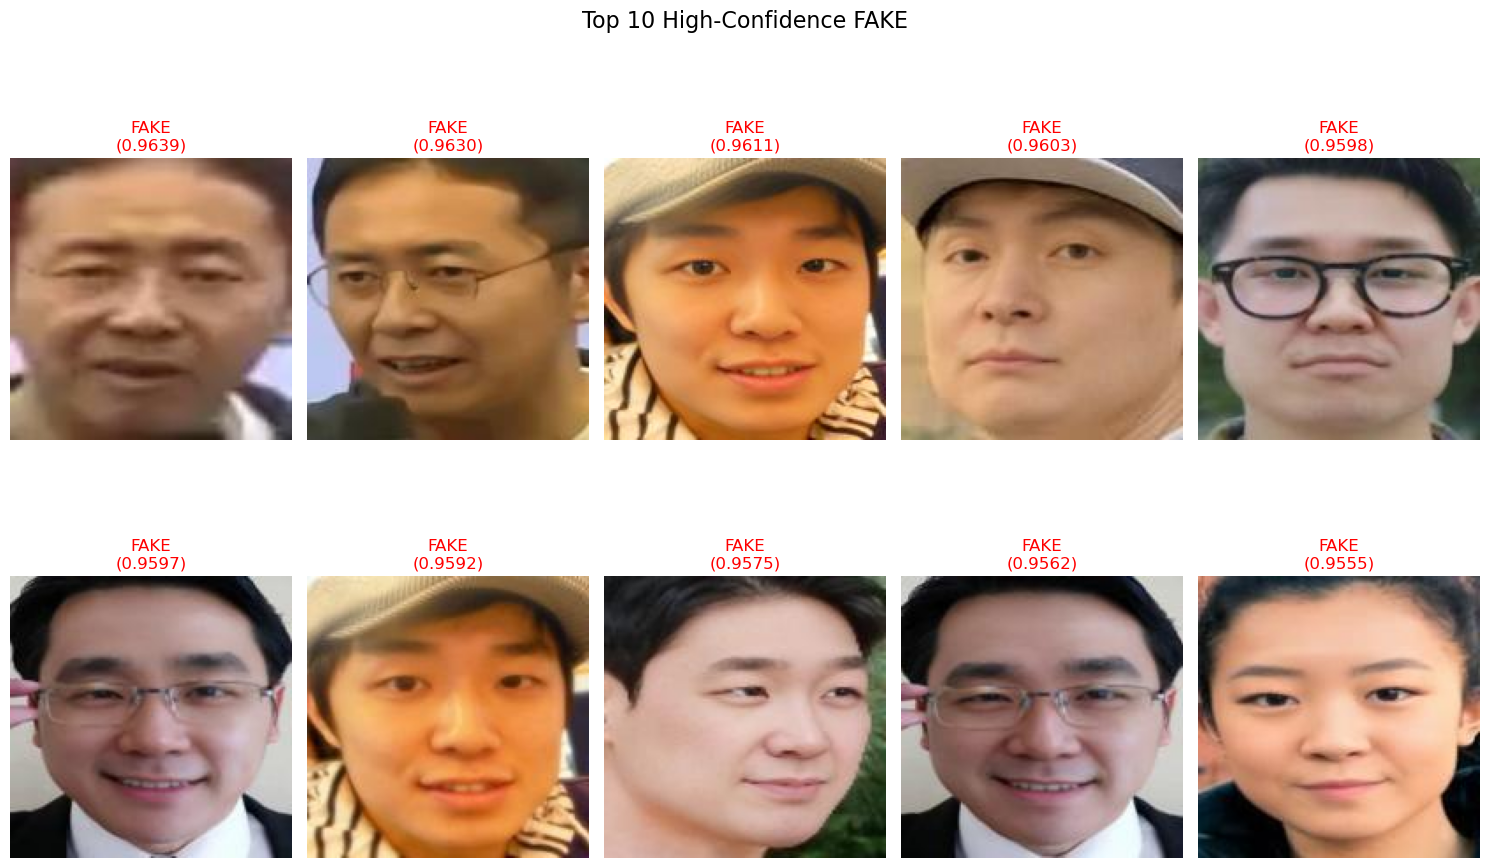

In [5]:
# 4. High Confidence FAKE (가장 가짜 같은 것들)
top_fake = valid_df.sort_values('prob', ascending=False).head(10)
show_samples(top_fake, "Top 10 High-Confidence FAKE")

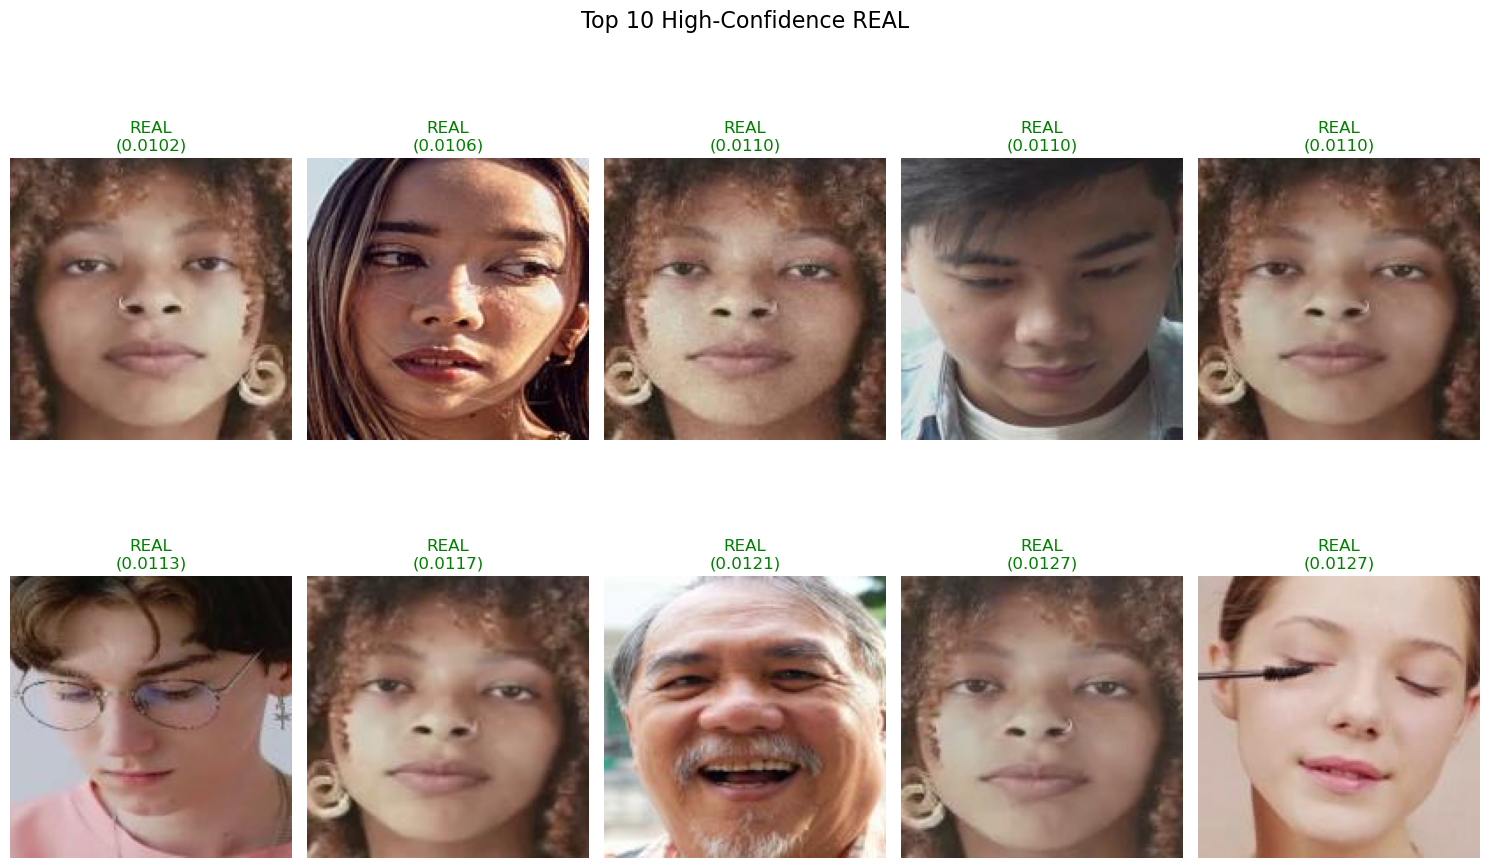

In [6]:
# 5. High Confidence REAL (가장 진짜 같은 것들)
top_real = valid_df.sort_values('prob', ascending=True).head(10)
show_samples(top_real, "Top 10 High-Confidence REAL")

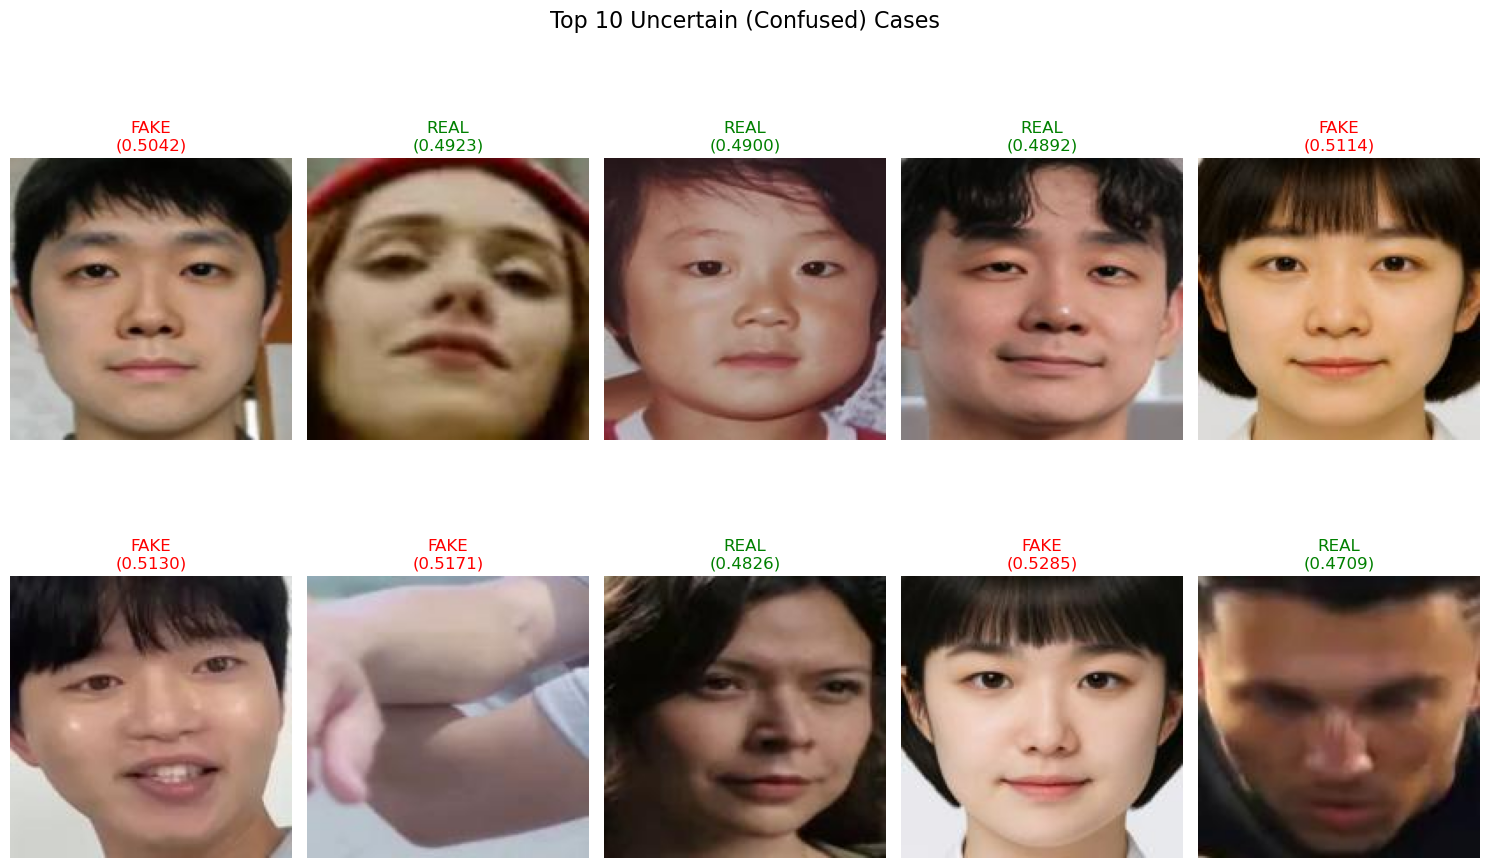

In [7]:
# 6. Most Uncertain (모델이 헷갈리는 것들 - 0.5 근처)
# abs(prob - 0.5)가 작은 순서
valid_df['uncertainty'] = abs(valid_df['prob'] - 0.5)
uncertain = valid_df.sort_values('uncertainty').head(10)
show_samples(uncertain, "Top 10 Uncertain (Confused) Cases")